# Land Acquisition Delay Prediction — Prototype

A quick end-to-end prototype for the *AI-powered Predictive Analytics System for Land Acquisition Delays* problem statement, built on the synthetic `land_acquisition_dummy_data.csv` dataset (500 mock projects).

**What this notebook does:**
1. Load + explore the dummy data
2. Feature engineering (encode categoricals, build the feature matrix)
3. Train a classifier to predict `risk_category` (Low / Medium / High) using **5-fold cross-validation**
4. Evaluate fold-by-fold performance + an aggregate confusion matrix
5. Explainability — which features actually drive the risk prediction
6. Train a regressor for `delay_probability`
7. **CUDA / GPU acceleration** — how to flip this whole pipeline onto a GPU, and when it's actually worth it

> ⚠️ This is a *prototype on synthetic data* — swap in real land-acquisition records later; the pipeline itself doesn't change.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, mean_absolute_error, r2_score
)

import xgboost as xgb

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
N_FOLDS = 5


## 2. Load the dummy dataset

In [2]:
df = pd.read_csv("data.csv")
print(df.shape)
df.head()


(500, 24)


,project_id,project_name,state,district,project_type,land_area_hectares,affected_families,compensation_status,compensation_disbursed_pct,approval_stage,...,rehabilitation_progress_pct,stakeholder_responsiveness_score,historical_district_delay_rate,inter_department_coordination_issues,project_start_date,planned_duration_days,expected_completion_date,delay_probability,actual_delay_days,risk_category
0,LA-0001,Power Transmission Line Project Pune-1,Maharashtra,Pune,Power Transmission Line,53.44,119,Not Disbursed,1.6,SIA Completed,...,97.0,8.5,0.60,Medium,2024-01-22,365,2025-01-21,0.200,214,Low
1,LA-0002,National Highway Project Howrah-2,West Bengal,Howrah,National Highway,27.57,58,Not Disbursed,2.9,SIA Completed,...,51.4,6.3,0.24,Low,2022-02-12,1460,2026-02-11,0.596,314,Medium
2,LA-0003,Airport Expansion Project Bhubaneswar-3,Odisha,Bhubaneswar,Airport Expansion,27.02,257,Partially Disbursed,19.2,Notification (Sec 11),...,18.5,9.7,0.27,Low,2021-11-15,545,2023-05-14,0.369,362,Medium
3,LA-0004,State Highway Project Ahmedabad-4,Gujarat,Ahmedabad,State Highway,20.02,27,Partially Disbursed,31.1,Award Declared,...,0.6,8.3,0.39,High,2023-07-30,1460,2027-07-29,0.980,571,High
4,LA-0005,State Highway Project Aurangabad-5,Maharashtra,Aurangabad,State Highway,22.76,103,Partially Disbursed,14.8,Rehabilitation Ongoing,...,12.0,7.4,0.32,Low,2022-01-29,365,2023-01-29,0.450,402,Medium


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   project_id                            500 non-null    str    
 1   project_name                          500 non-null    str    
 2   state                                 500 non-null    str    
 3   district                              500 non-null    str    
 4   project_type                          500 non-null    str    
 5   land_area_hectares                    500 non-null    float64
 6   affected_families                     500 non-null    int64  
 7   compensation_status                   500 non-null    str    
 8   compensation_disbursed_pct            500 non-null    float64
 9   approval_stage                        500 non-null    str    
 10  days_since_notification               500 non-null    int64  
 11  legal_disputes_count          

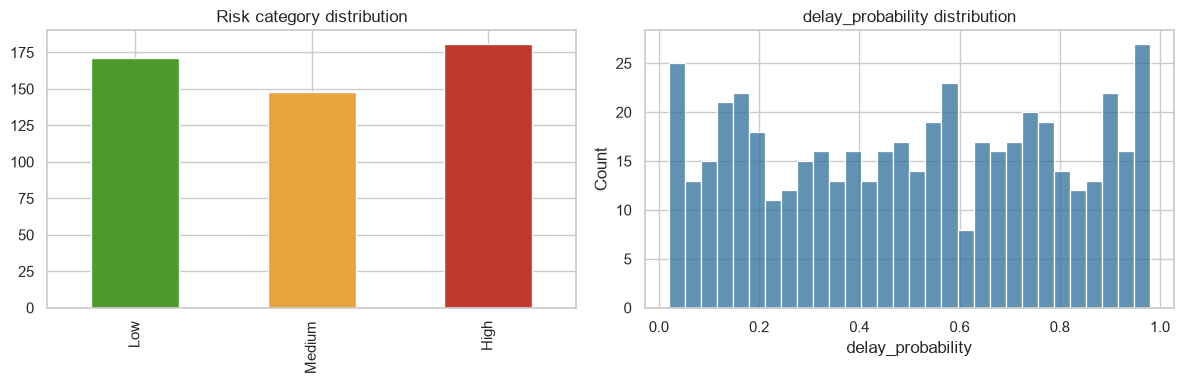

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["risk_category"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", ax=ax[0], color=["#4C9A2A", "#E8A33D", "#C0392B"]
)
ax[0].set_title("Risk category distribution")
ax[0].set_xlabel("")

sns.histplot(df["delay_probability"], bins=30, ax=ax[1], color="#2C6E9B")
ax[1].set_title("delay_probability distribution")
plt.tight_layout()
plt.show()


## 3. Feature engineering

`project_id` / `project_name` are identifiers, not signal. Dates are converted to a couple of
numeric features. Everything else maps directly to the risk factors called out in the problem
statement (compensation, legal disputes, rehabilitation, possession, stakeholder responsiveness,
historical performance, inter-department coordination).

In [5]:
work = df.copy()

work["project_start_date"] = pd.to_datetime(work["project_start_date"])
work["expected_completion_date"] = pd.to_datetime(work["expected_completion_date"])
work["project_age_days"] = (pd.Timestamp("2026-08-23") - work["project_start_date"]).dt.days

drop_cols = ["project_id", "project_name", "project_start_date", "expected_completion_date",
             "actual_delay_days", "delay_probability", "risk_category"]

categorical_cols = ["state", "district", "project_type", "compensation_status", "approval_stage",
                     "legal_dispute_status", "possession_status", "inter_department_coordination_issues"]

numeric_cols = [c for c in work.columns if c not in drop_cols + categorical_cols]

X = work.drop(columns=drop_cols)
y_class = work["risk_category"]
y_reg = work["delay_probability"]

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)


Numeric features: ['land_area_hectares', 'affected_families', 'compensation_disbursed_pct', 'days_since_notification', 'legal_disputes_count', 'rehabilitation_progress_pct', 'stakeholder_responsiveness_score', 'historical_district_delay_rate', 'planned_duration_days', 'project_age_days']
Categorical features: ['state', 'district', 'project_type', 'compensation_status', 'approval_stage', 'legal_dispute_status', 'possession_status', 'inter_department_coordination_issues']


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


## 4. Classifier — 5-fold cross-validation

Predicting `risk_category` (Low / Medium / High) with a Random Forest, evaluated across **5 stratified folds**
so every fold keeps the same class balance. This is the "risk scoring" engine behind the dashboard.

In [7]:
label_encoder = LabelEncoder()
y_class_enc = label_encoder.fit_transform(y_class)  # Low=?, Medium=?, High=? -> check classes_
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_results = []
oof_preds = np.zeros(len(X), dtype=int)
oof_proba = np.zeros((len(X), len(label_encoder.classes_)))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_class_enc), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_class_enc[train_idx], y_class_enc[val_idx]

    clf = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
        )),
    ])
    clf.fit(X_train, y_train)

    preds = clf.predict(X_val)
    proba = clf.predict_proba(X_val)

    oof_preds[val_idx] = preds
    oof_proba[val_idx] = proba

    acc = accuracy_score(y_val, preds)
    f1_macro = f1_score(y_val, preds, average="macro")
    auc_ovr = roc_auc_score(y_val, proba, multi_class="ovr")

    fold_results.append({"fold": fold, "accuracy": acc, "f1_macro": f1_macro, "roc_auc_ovr": auc_ovr})
    print(f"Fold {fold}: accuracy={acc:.3f}  f1_macro={f1_macro:.3f}  roc_auc_ovr={auc_ovr:.3f}")

fold_df = pd.DataFrame(fold_results)
print("\nMean \u00b1 std across 5 folds:")
print(fold_df[["accuracy", "f1_macro", "roc_auc_ovr"]].agg(["mean", "std"]))


{'High': 0, 'Low': 1, 'Medium': 2}
Fold 1: accuracy=0.670  f1_macro=0.616  roc_auc_ovr=0.828
Fold 2: accuracy=0.690  f1_macro=0.658  roc_auc_ovr=0.860
Fold 3: accuracy=0.670  f1_macro=0.647  roc_auc_ovr=0.827
Fold 4: accuracy=0.680  f1_macro=0.648  roc_auc_ovr=0.836
Fold 5: accuracy=0.710  f1_macro=0.673  roc_auc_ovr=0.844

Mean ± std across 5 folds:
      accuracy  f1_macro  roc_auc_ovr
mean  0.684000  0.648474     0.838870
std   0.016733  0.020904     0.013631


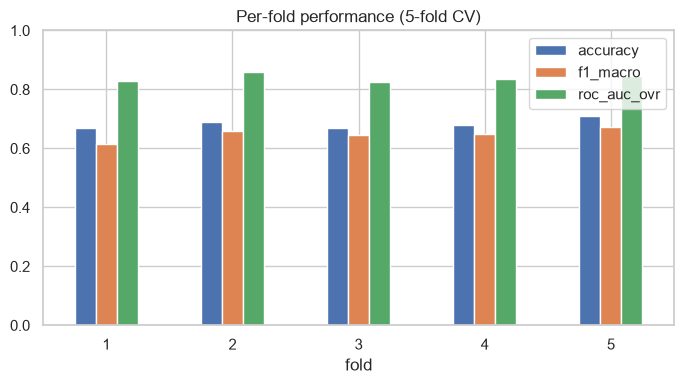

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
fold_df.set_index("fold")[["accuracy", "f1_macro", "roc_auc_ovr"]].plot(kind="bar", ax=ax)
ax.set_title("Per-fold performance (5-fold CV)")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

        High       0.71      0.84      0.77       181
         Low       0.73      0.83      0.78       171
      Medium       0.53      0.32      0.40       148

    accuracy                           0.68       500
   macro avg       0.66      0.66      0.65       500
weighted avg       0.66      0.68      0.66       500



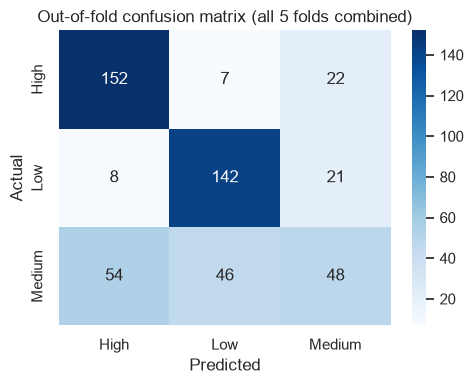

In [9]:
print(classification_report(y_class_enc, oof_preds, target_names=label_encoder.classes_))

cm = confusion_matrix(y_class_enc, oof_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Out-of-fold confusion matrix (all 5 folds combined)")
plt.tight_layout()
plt.show()


## 5. Explainability — which features drive the risk score

The problem statement explicitly asks for *"Explainable AI techniques to ensure transparency."*
Feature importances from the Random Forest (averaged across the 5 folds) give a first pass at this —
swap in SHAP later for per-project explanations in the dashboard.

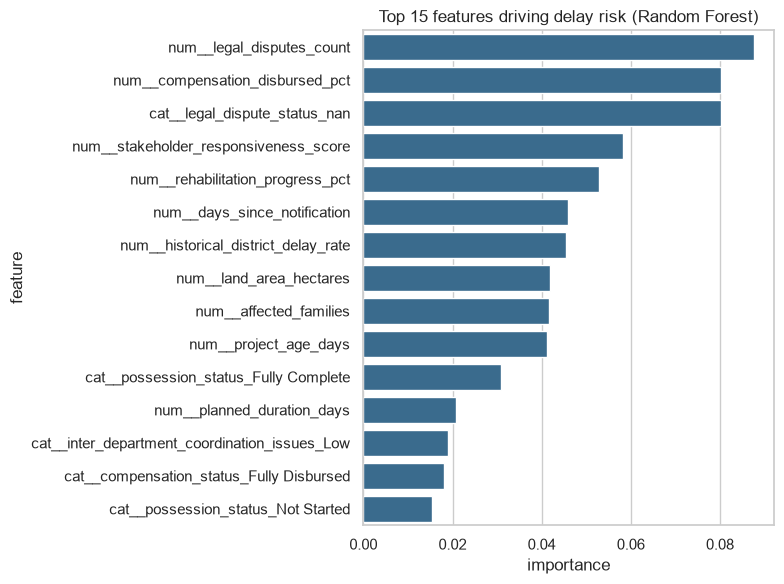

In [10]:
final_clf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])
final_clf.fit(X, y_class_enc)

feature_names = final_clf.named_steps["prep"].get_feature_names_out()
importances = final_clf.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", color="#2C6E9B")
plt.title("Top 15 features driving delay risk (Random Forest)")
plt.tight_layout()
plt.show()


## 6. Regressor — predicting `delay_probability` (5-fold CV)

Same 5-fold setup, this time predicting the continuous delay probability with XGBoost — this is also
the model we'll GPU-accelerate in the next section.

In [11]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

reg_fold_results = []
oof_reg_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_reg.iloc[train_idx], y_reg.iloc[val_idx]

    reg = Pipeline([
        ("prep", preprocessor),
        ("model", xgb.XGBRegressor(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            tree_method="hist",   # see CUDA section below for device="cuda"
        )),
    ])
    reg.fit(X_train, y_train)
    preds = reg.predict(X_val)
    oof_reg_preds[val_idx] = preds

    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    reg_fold_results.append({"fold": fold, "mae": mae, "r2": r2})
    print(f"Fold {fold}: MAE={mae:.4f}  R2={r2:.3f}")

reg_fold_df = pd.DataFrame(reg_fold_results)
print("\nMean \u00b1 std across 5 folds:")
print(reg_fold_df[["mae", "r2"]].agg(["mean", "std"]))


Fold 1: MAE=0.1142  R2=0.732
Fold 2: MAE=0.1076  R2=0.800
Fold 3: MAE=0.1061  R2=0.811
Fold 4: MAE=0.1045  R2=0.727
Fold 5: MAE=0.1190  R2=0.732

Mean ± std across 5 folds:
           mae        r2
mean  0.110261  0.760524
std   0.006109  0.041375


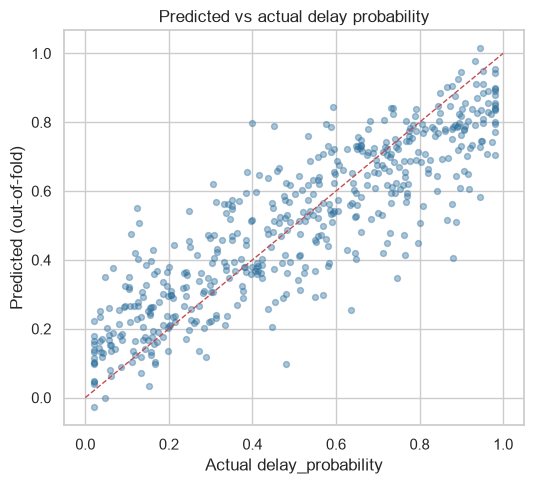

In [12]:
plt.figure(figsize=(5.5, 5))
plt.scatter(y_reg, oof_reg_preds, alpha=0.4, s=18, color="#2C6E9B")
plt.plot([0, 1], [0, 1], "r--", linewidth=1)
plt.xlabel("Actual delay_probability")
plt.ylabel("Predicted (out-of-fold)")
plt.title("Predicted vs actual delay probability")
plt.tight_layout()
plt.show()


## 7. CUDA / GPU acceleration

**Short answer: yes, but on 500 rows it won't help — GPU speedups on tabular data only show up once
you're training on tens/hundreds of thousands of rows, or many hyperparameter-search runs back to
back.** On this dummy dataset, the fixed overhead of moving data to the GPU costs more time than
it saves. Worth wiring up now anyway so the notebook is ready when you plug in a real, larger
dataset.

Two realistic paths, both plug into the pipeline above with **zero change to the CV loop or the
preprocessing**:

**A. XGBoost's built-in GPU support (`device="cuda"`)** — the easiest win. XGBoost ships CUDA
kernels in the standard `pip install xgboost` wheel; you don't need a separate GPU build. Just
change one parameter:

```python
xgb.XGBRegressor(..., tree_method="hist", device="cuda")   # instead of device="cpu"
```

Same for `xgb.XGBClassifier`. Requires an NVIDIA GPU + CUDA driver on the machine actually running
the notebook (this sandbox has neither, so the cell below auto-detects and falls back to CPU).

**B. RAPIDS cuML** — for the Random Forest step, scikit-learn itself has no GPU path. RAPIDS'
`cuml.ensemble.RandomForestClassifier` is a drop-in replacement with (mostly) the same API,
running entirely on GPU — useful once your feature matrix gets large. Install via
`conda install -c rapidsai -c conda-forge -c nvidia cuml` (RAPIDS isn't pip-installable the
normal way, and needs a matching CUDA toolkit version).

The cell below detects whether a CUDA device is actually available and only switches XGBoost onto
GPU if so — safe to run on any machine.

In [13]:
def cuda_is_available():
    """Best-effort CUDA detection without requiring torch."""
    try:
        import subprocess
        out = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=5)
        return out.returncode == 0
    except Exception:
        return False

USE_CUDA = cuda_is_available()
device = "cuda" if USE_CUDA else "cpu"
print(f"CUDA available: {USE_CUDA}  -> XGBoost device = '{device}'")


CUDA available: True  -> XGBoost device = 'cuda'


In [14]:
import time

gpu_fold_results = []
t0 = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_reg.iloc[train_idx], y_reg.iloc[val_idx]

    reg = Pipeline([
        ("prep", preprocessor),
        ("model", xgb.XGBRegressor(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            tree_method="hist",
            device=device,          # <-- the only line that changes between CPU/GPU
        )),
    ])
    reg.fit(X_train, y_train)
    preds = reg.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    gpu_fold_results.append({"fold": fold, "mae": mae})

elapsed = time.time() - t0
print(f"5-fold training on device='{device}' took {elapsed:.2f}s")
pd.DataFrame(gpu_fold_results)


5-fold training on device='cuda' took 9.94s


,fold,mae
0,1,0.110822
1,2,0.109569
2,3,0.105888
3,4,0.102059
4,5,0.116151


## 8. Save the model

Persist the fitted classifier + regressor so the FastAPI backend can load them directly for
the dashboard's `/predict` endpoint.

In [15]:
joblib.dump(final_clf, "risk_classifier.joblib")

final_reg = Pipeline([
    ("prep", preprocessor),
    ("model", xgb.XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        tree_method="hist", device=device,
    )),
])
final_reg.fit(X, y_reg)
joblib.dump(final_reg, "delay_regressor.joblib")
joblib.dump(label_encoder, "risk_label_encoder.joblib")

print("Saved: risk_classifier.joblib, delay_regressor.joblib, risk_label_encoder.joblib")


Saved: risk_classifier.joblib, delay_regressor.joblib, risk_label_encoder.joblib


## 9. Next steps

- Swap this dummy CSV for real project records — the pipeline, folds, and CUDA switch don't need to change.
- Wire `risk_classifier.joblib` / `delay_regressor.joblib` into a FastAPI `/predict` endpoint.
- Add SHAP for per-project explanations (`shap.TreeExplainer` works directly on the fitted XGBoost/RandomForest models).
- Feed `state` / `district` groupings into the GIS dashboard for district-wise delay trend maps.
